In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [16]:
df_DA_GER = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()
df_DA_GER = df_DA_GER.dropna(subset=['salary_year_avg'])
df_DA_GER_explode = df_DA_GER.explode('job_skills')

df_skills_cat = df['job_type_skills'].copy()
df_skills_cat = df_skills_cat.drop_duplicates()
df_skills_cat = df_skills_cat.dropna()

skills_cat_dict = {}
for row in df_skills_cat:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in skills_cat_dict:
            skills_cat_dict[key] += value
        else:
            skills_cat_dict[key] = value
for key, value in skills_cat_dict.items():
    skills_cat_dict[key] = list(set(value))

df_skills_cat = pd.DataFrame(list(skills_cat_dict.items()), columns=['technology', 'skills'])
df_skills_cat = df_skills_cat.explode('skills')

In [17]:
#fix categories for plot
category_fix = {'sql': 'database', 'nosql': 'database', 'github': 'developer_tools'}

df_skills_cat['technology_clean'] = (df_skills_cat['technology'].copy())

df_skills_cat['technology_clean'] = (
    df_skills_cat.apply(lambda row: category_fix.get(row['skills'], row['technology']), axis=1))

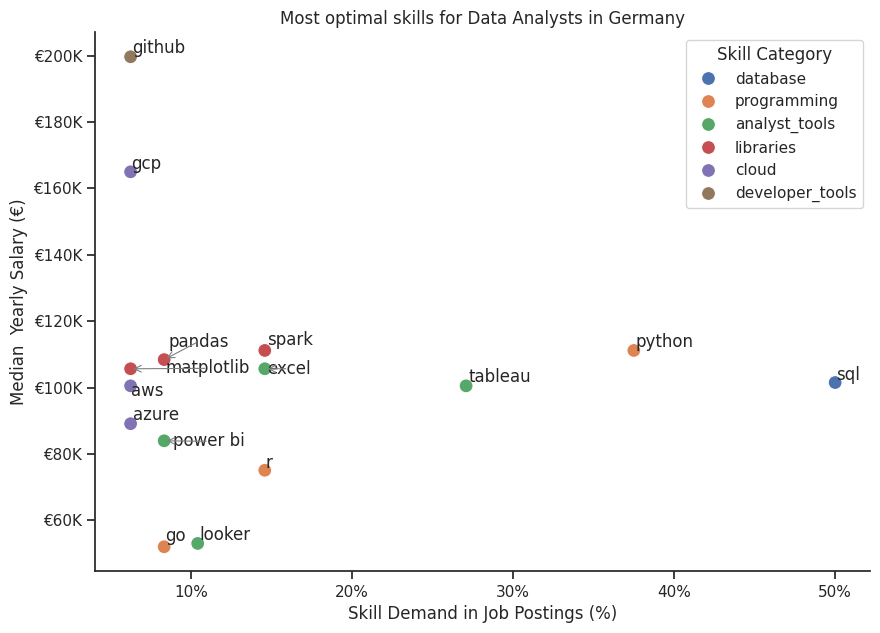

In [ ]:
from adjustText import adjust_text

skill_stats = df_DA_GER_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
top_skills = skill_stats.sort_values(by='count', ascending=False)
top_skills = top_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
job_count = len(df_DA_GER)
top_skills['skill_percent'] = top_skills['skill_count'] / job_count * 100
top_skills_plot = top_skills[top_skills['skill_percent'] > 5]
top_skills_plot = top_skills_plot.merge(df_skills_cat, left_on='job_skills', right_on='skills')
top_skills_plot = top_skills_plot.set_index('skills')

sns.set_theme(style='ticks')
plt.figure(figsize=(10, 7))
sns.scatterplot(data=top_skills_plot, x='skill_percent', y='median_salary', hue='technology_clean', s=100)
sns.despine()
plt.xlabel('Skill Demand in Job Postings (%)')
plt.ylabel('Median  Yearly Salary (€)')
plt.title('Most optimal skills for Data Analysts in Germany')
texts = []
for i, txt in enumerate(top_skills_plot.index):
    texts.append(plt.text(top_skills_plot['skill_percent'].iloc[i], top_skills_plot['median_salary'].iloc[i], txt))
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
    expand_points=(1.2, 1.4),
    expand_text=(1.2, 1.4)
)
ax = plt.gca()
ax.legend(title='Skill Category')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'€{int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}%'))
plt.show()
